In [389]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import re

In [390]:
df=pd.read_csv('/content/car_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Car Name      1009 non-null   object
 1   Kilometers    1009 non-null   int64 
 2   Fuel          1009 non-null   object
 3   Transmission  1009 non-null   object
 4   Registration  1009 non-null   object
 5   EMI           1009 non-null   object
 6   Final Price   1009 non-null   object
 7   Location      1009 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.2+ KB


In [391]:
df.head()

,Car Name,Kilometers,Fuel,Transmission,Registration,EMI,Final Price,Location
0,2015 Hyundai Eon,43518,Petrol,Manual,DL-11,"EMI ₹8,826/m*",Account,"Piyush Mahendra Mall, opp. Dussehra Ground, N..."
1,2019 Maruti Swift,58358,CNG,Manual,DL-13,₹5.64L₹5.00 lakh+ other charges,₹1.77 lakh,"M3M Urbana, Golf Course Ext., Gurugram"
2,2015 Maruti Wagon R 1.0,65974,CNG,Manual,DL-14,Not available on EMI,₹4.05 lakh,"Gaur City mall, Multilevel parking, Greater N..."
3,2015 Honda Amaze,40807,Petrol,Manual,HR-21,₹3.81L₹3.13 lakh+ other charges,₹2.13 lakh,"M3M Urbana, Golf Course Ext., Gurugram"
4,2019 Maruti Swift,57241,Petrol,Manual,DL-10,"EMI ₹8,120/m*",₹2.35 lakh,"GNB Mall, Raj Nagar Extension, Ghaziabad"


In [392]:
df['Car Name'].value_counts()

,count
Car Name,
2015 Maruti Wagon R 1.0,27
2012 Maruti Wagon R 1.0,26
2016 Maruti Swift,19
2019 Maruti Swift,16
2017 Renault Kwid,15
...,...
2024 Maruti Ertiga,1
2013 Maruti Alto 800,1
2021 Maruti IGNIS,1


In [393]:
df['Car Name'].nunique()

339

In [394]:
df['Location'].value_counts()

,count
Location,
"M3M Urbana, Golf Course Ext., Gurugram",52
"Metro Walk, Rohini, New Delhi",46
"Piyush Mahendra Mall, opp. Dussehra Ground, NIT - 3",41
"GNB Mall, Raj Nagar Extension, Ghaziabad",36
"Gaur City mall, Multilevel parking, Greater Noida",33
...,...
Ssec 21 763 on main road near gate 5 Kaithal,1
Friends Colony Kaithal Haryana,1
Kaithal Haryana India Kaithal,1


In [395]:
df['Location'].nunique()

651

In [396]:
df.isnull().sum()

,0
Car Name,0
Kilometers,0
Fuel,0
Transmission,0
Registration,0
EMI,0
Final Price,0
Location,0


In [397]:
df.duplicated().sum()

np.int64(0)

In [398]:
df['Final Price'].value_counts()

,count
Final Price,
Account,355
₹2.00 lakh,13
₹2.20 lakh,10
₹1.90 lakh,9
₹3.00 lakh,9
...,...
₹12.38 lakh,1
₹3.41 lakh,1
₹5.34 lakh,1


In [399]:
(df['Final Price'].value_counts()/len(df))*100

,count
Final Price,
Account,35.183350
₹2.00 lakh,1.288404
₹2.20 lakh,0.991080
₹1.90 lakh,0.891972
₹3.00 lakh,0.891972
...,...
₹12.38 lakh,0.099108
₹3.41 lakh,0.099108
₹5.34 lakh,0.099108


In [400]:
df = df[~df['Final Price'].astype(str).str.contains('account', case=False, na=False)]
df.shape

(654, 8)

In [401]:
df['Final Price'] = (df['Final Price'].str.replace('₹', '', regex=False).str.replace('lakh', '', regex=False).str.strip().astype(float)* 100000).astype(int)

In [402]:
df['Final Price'].value_counts()

,count
Final Price,
200000,13
220000,10
190000,9
300000,9
235000,9
...,...
1238000,1
341000,1
534000,1


In [403]:
df['state']= df['Registration'].str[:2]
df['state'].value_counts()

,count
state,
HR,298
UP,157
PB,68
WB,40
CH,37
DL,23
UK,10
BR,6
MP,3


In [404]:
df.describe()

,Kilometers,Final Price
count,654.000000,6.540000e+02
mean,83142.590214,3.751666e+05
std,38909.813155,3.006013e+05
min,3496.000000,6.400000e+04
25%,56833.000000,1.900000e+05
50%,77141.000000,3.000000e+05
75%,102664.750000,4.550000e+05
max,252995.000000,2.874000e+06


# ***DATA ANALYSIS :***

1. What is the overall distribution of used car prices, and are there any significant outliers?

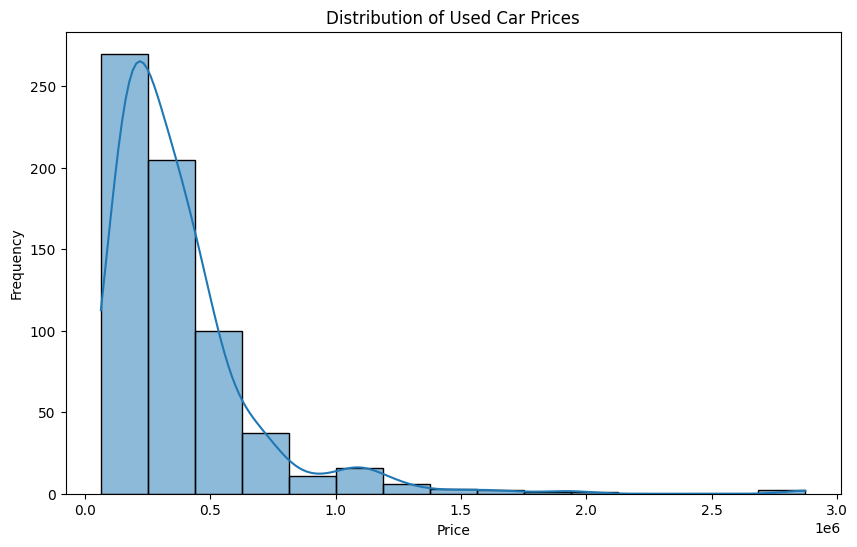

In [405]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Final Price'], bins=15, kde=True)
plt.title('Distribution of Used Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

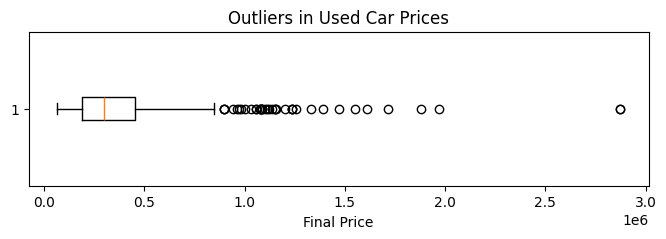

In [406]:
plt.figure(figsize=(8,2))
plt.boxplot(df["Final Price"],vert=False)
plt.title("Outliers in Used Car Prices")
plt.xlabel("Final Price")
plt.show()

In [407]:
#Detect outliers using IQR
Q1 = df["Final Price"].quantile(0.25)
Q3 = df["Final Price"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[
    (df["Final Price"] < Q1 - 1.5 * IQR) |
    (df["Final Price"] > Q3 + 1.5 * IQR)
]
print("Number of Outliers:", len(outliers))
print(outliers[["Car Name", "Final Price"]])

Number of Outliers: 39
                           Car Name  Final Price
56               2022 Mahindra Thar      1235000
58             2019 Volkswagen Polo      1055000
99        2017 Maruti Vitara Brezza      2874000
101         2013 Maruti Wagon R 1.0      1078000
211              2024 Maruti BREZZA      1150000
217            2018 Toyota Fortuner       900000
223         2011 Maruti Wagon R 1.0       960000
233                 2017 Honda WR-V      1120000
235               2021 Jeep Compass      1030000
236         2018 Maruti Wagon R 1.0      1610000
238              2023 Maruti Baleno      1880000
239                 2021 Tata Tiago      1970000
260       2016 Maruti Vitara Brezza      1100000
261              2020 Hyundai VENUE      1158000
298            2016 Maruti Alto 800      1088000
312                2013 Hyundai Eon      1200000
314          2016 Hyundai Grand i10      1389000
391               2018 Maruti Swift       900000
419           2020 Volkswagen Vento      12580

2. Which are the top 10 most expensive and top 10 least expensive cars?

In [408]:
# Top 10 expensive cars
top10_expensive = (df.sort_values(by="Final Price", ascending=False)[["Car Name", "Final Price"]].head(10))
print("Top 10 Most Expensive Cars")
print(top10_expensive)

# Top 10 cheapest cars
top10_cheapest= df[df['Final Price'] > 0].sort_values(by="Final Price", ascending=True)[["Car Name", "Final Price"]].head(10)
print("Top 10 Least Expensive Cars")
print(top10_cheapest)

Top 10 Most Expensive Cars
                      Car Name  Final Price
959        2023 Nissan MAGNITE      2874000
99   2017 Maruti Vitara Brezza      2874000
239            2021 Tata Tiago      1970000
238         2023 Maruti Baleno      1880000
718        2016 Maruti Celerio      1713000
236    2018 Maruti Wagon R 1.0      1610000
622    2013 Maruti Wagon R 1.0      1550000
427            2023 KIA SELTOS      1470000
314     2016 Hyundai Grand i10      1389000
544    2015 Maruti Swift Dzire      1330000
Top 10 Least Expensive Cars
                    Car Name  Final Price
674          2020 KIA SELTOS        64000
809  2012 Maruti Wagon R 1.0        64000
436  2017 Maruti Wagon R 1.0        66000
400         2015 Hyundai i10        70000
249            2023 MG ASTOR        73000
169        2019 Maruti Swift        75000
85   2016 Maruti Swift Dzire        80000
727   2014 Hyundai Elite i20        80000
945        2016 Renault Kwid        80000
822  2015 Hyundai i20 Active        84000

3. How does the average selling price vary across different car brands?

In [409]:
# Extract brand (first word from Car Name)
df["Brand"] = df["Car Name"].str.split().str[1]

# Average price by brand
brand_price = (df.groupby("Brand")["Final Price"].mean().sort_values(ascending=False))
print(brand_price)

Brand
Jeep          1.030000e+06
Nissan        7.561111e+05
KIA           4.166470e+05
Volkswagen    4.075292e+05
Chevrolet     4.003749e+05
Volvo         3.934995e+05
Toyota        3.922800e+05
Honda         3.916765e+05
Tata          3.888793e+05
Skoda         3.848571e+05
Maruti        3.780901e+05
Mahindra      3.663750e+05
Ford          3.589473e+05
Hyundai       3.532065e+05
Renault       3.231929e+05
MG            3.059999e+05
Datsun        3.015455e+05
Audi          1.835000e+05
Jaguar        1.500000e+05
Name: Final Price, dtype: float64


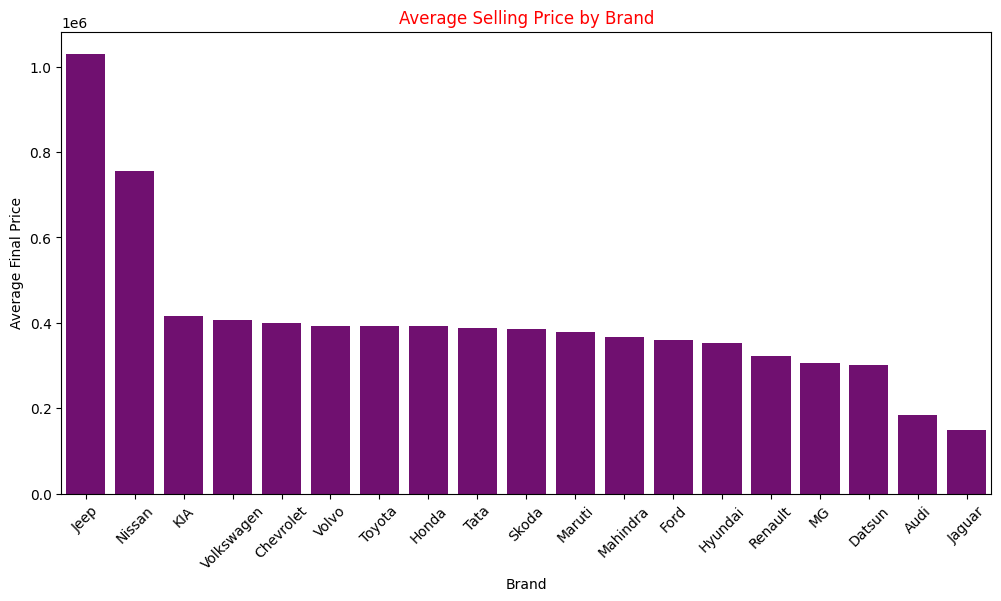

In [410]:
# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=brand_price.index, y=brand_price.values,color='purple')
plt.title("Average Selling Price by Brand",color='red')
plt.xlabel("Brand")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

4. How does the average selling price vary across the car first bought in the year?

In [411]:
# Extract brand (first word from Car Name)
df["year"]= df["Car Name"].str.split().str[0]
df['year']=df['year'].astype(int)

# Average price by brand
year_price = (df.groupby("year")["Final Price"].mean().sort_values(ascending=False))
print(brand_price)

Brand
Jeep          1.030000e+06
Nissan        7.561111e+05
KIA           4.166470e+05
Volkswagen    4.075292e+05
Chevrolet     4.003749e+05
Volvo         3.934995e+05
Toyota        3.922800e+05
Honda         3.916765e+05
Tata          3.888793e+05
Skoda         3.848571e+05
Maruti        3.780901e+05
Mahindra      3.663750e+05
Ford          3.589473e+05
Hyundai       3.532065e+05
Renault       3.231929e+05
MG            3.059999e+05
Datsun        3.015455e+05
Audi          1.835000e+05
Jaguar        1.500000e+05
Name: Final Price, dtype: float64


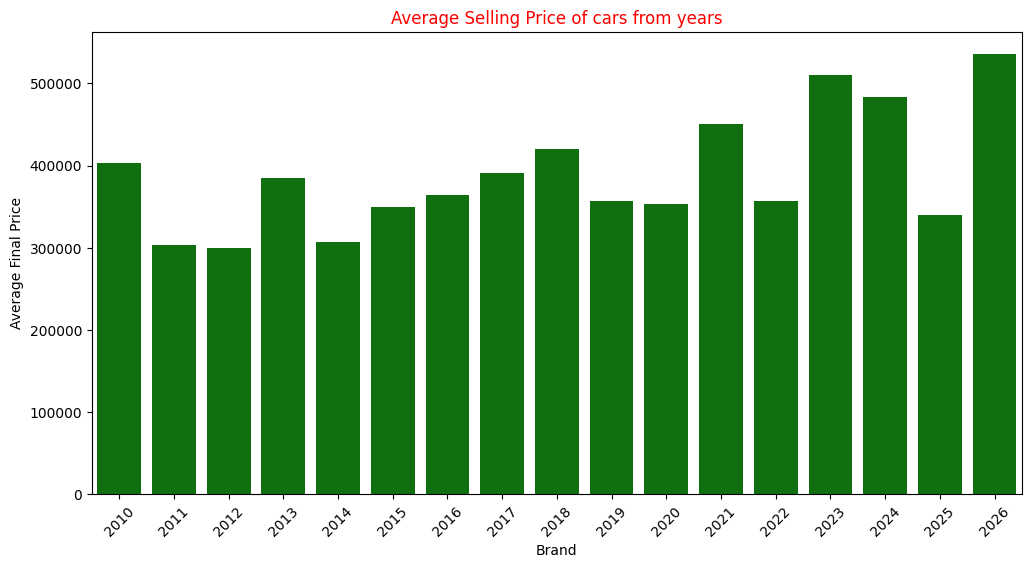

In [412]:
# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x=year_price.index, y=year_price.values,color='green')
plt.title("Average Selling Price of cars from years",color='red')
plt.xlabel("Brand")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

5. Which car models have the highest median resale value?

In [413]:
model_median = (df.groupby("Car Name")["Final Price"].median().sort_values(ascending=False).head(10))
print("Top 10 Models by Median Resale Value")
print(model_median)

Top 10 Models by Median Resale Value
Car Name
2021 Tata Tiago          1970000.0
2023 Maruti Baleno       1880000.0
2016 Maruti Celerio      1713000.0
2020 Volkswagen Vento    1258000.0
2021 Maruti XL6          1235000.0
2013 Chevrolet Sail      1150000.0
2022 Mahindra Thar       1066500.0
2021 Jeep Compass        1030000.0
2023 Maruti Celerio      1000000.0
2023 KIA SELTOS           885000.0
Name: Final Price, dtype: float64


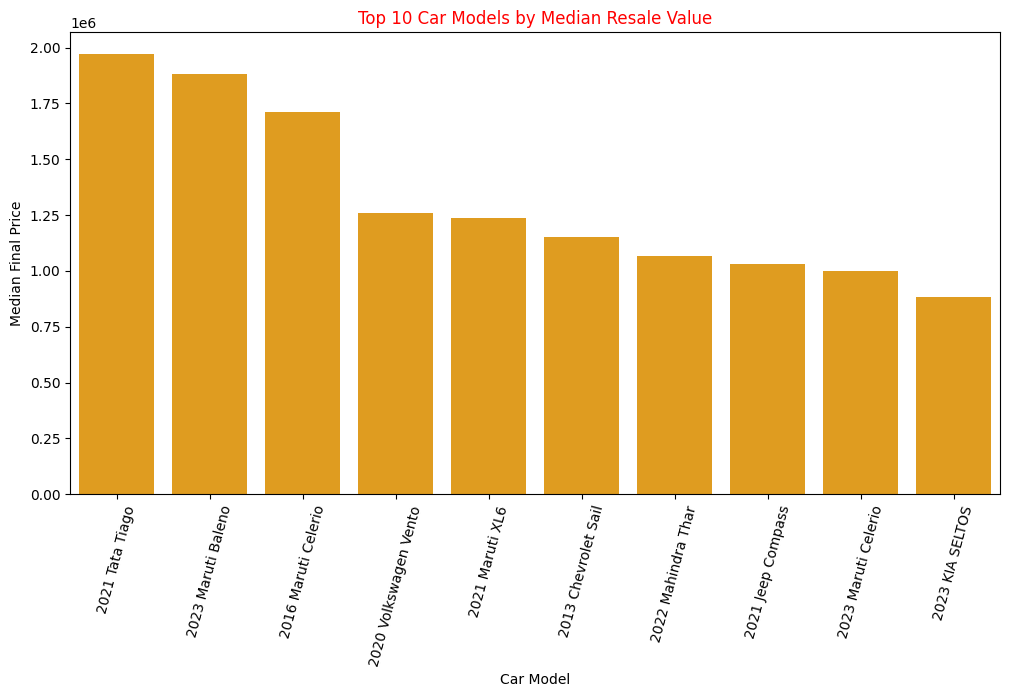

In [414]:
# Visusalization
plt.figure(figsize=(12,6))
sns.barplot(x=model_median.index, y=model_median.values,color='orange')
plt.title("Top 10 Car Models by Median Resale Value",color='red')
plt.xlabel("Car Model")
plt.ylabel("Median Final Price")
plt.xticks(rotation=75)
plt.show()

6. What percentage of listings fall into budget, mid-range, and premium price segments?

In [415]:
segments = {
    "Budget": (df["Final Price"] < 500000).sum(),
    "Mid-range": ((df["Final Price"] >= 500000) & (df["Final Price"] <= 1500000)).sum(),
    "Premium": (df["Final Price"] > 1500000).sum()
}
# Convert to percentages
total = len(df)
percentages = {k: round(v / total * 100, 2) for k, v in segments.items()}
print(percentages)

{'Budget': np.float64(80.58), 'Mid-range': np.float64(18.35), 'Premium': np.float64(1.07)}


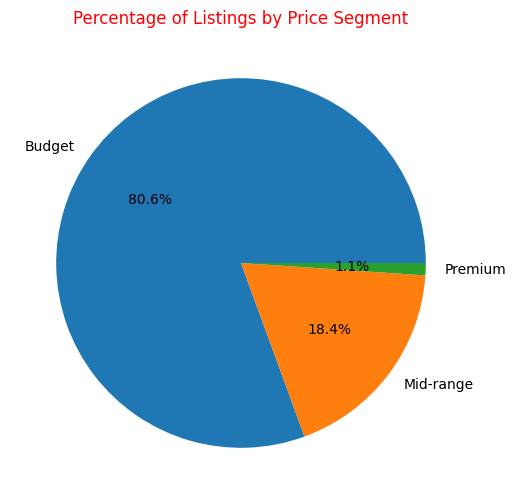

In [416]:
# visualization
plt.figure(figsize=(6, 6))
plt.pie(percentages.values(),labels=percentages.keys(),autopct="%1.1f%%",)
plt.title("Percentage of Listings by Price Segment",color='red')
plt.show()

7. Which brands have the highest number of cars listed for sale?

In [417]:
brand_counts = df["Brand"].value_counts()
print(brand_counts)

Brand
Maruti        233
Hyundai       121
Tata           58
Renault        57
Honda          34
Toyota         25
Mahindra       24
Ford           19
Volkswagen     17
KIA            17
Datsun         11
Nissan          9
MG              8
Chevrolet       8
Skoda           7
Volvo           2
Audi            2
Jaguar          1
Jeep            1
Name: count, dtype: int64


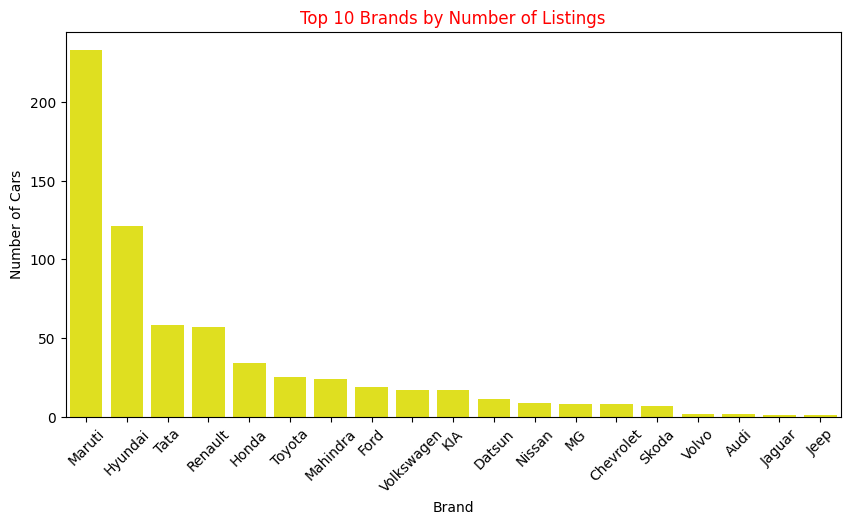

In [418]:
#Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_counts.index, y=brand_counts.values,color="yellow")
plt.title("Top 10 Brands by Number of Listings",color='red')
plt.xlabel("Brand")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)
plt.show()

8. Which brands command the highest average resale prices?

In [419]:
avg_price = (df.groupby("Brand")["Final Price"].mean().sort_values(ascending=False)).head(10)
print(avg_price)

Brand
Jeep          1.030000e+06
Nissan        7.561111e+05
KIA           4.166470e+05
Volkswagen    4.075292e+05
Chevrolet     4.003749e+05
Volvo         3.934995e+05
Toyota        3.922800e+05
Honda         3.916765e+05
Tata          3.888793e+05
Skoda         3.848571e+05
Name: Final Price, dtype: float64


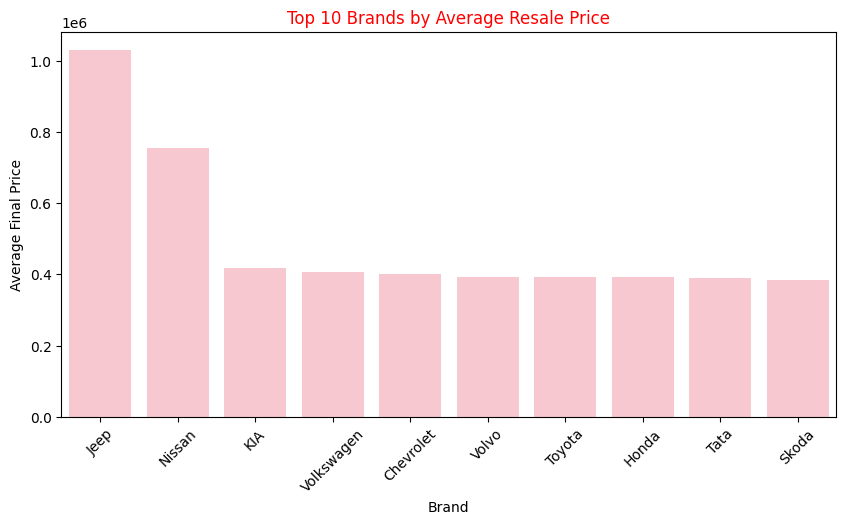

In [420]:
# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price.index, y=avg_price.values,color='pink')
plt.title("Top 10 Brands by Average Resale Price",color='red')
plt.xlabel("Brand")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

9. Which car models are most frequently available in the market?

In [421]:
model_counts = df["Car Name"].value_counts().head(15)
print(model_counts)

Car Name
2016 Maruti Swift          15
2015 Maruti Wagon R 1.0    15
2012 Maruti Wagon R 1.0    14
2016 Hyundai Elite i20     10
2019 Maruti Swift          10
2017 Renault Kwid          10
2018 Renault Kwid           9
2013 Hyundai Eon            9
2019 Honda Amaze            9
2016 Renault Kwid           9
2020 KIA SELTOS             7
2023 Tata PUNCH             7
2019 Tata NEXON             7
2013 Maruti Swift Dzire     7
2012 Maruti Swift Dzire     7
Name: count, dtype: int64


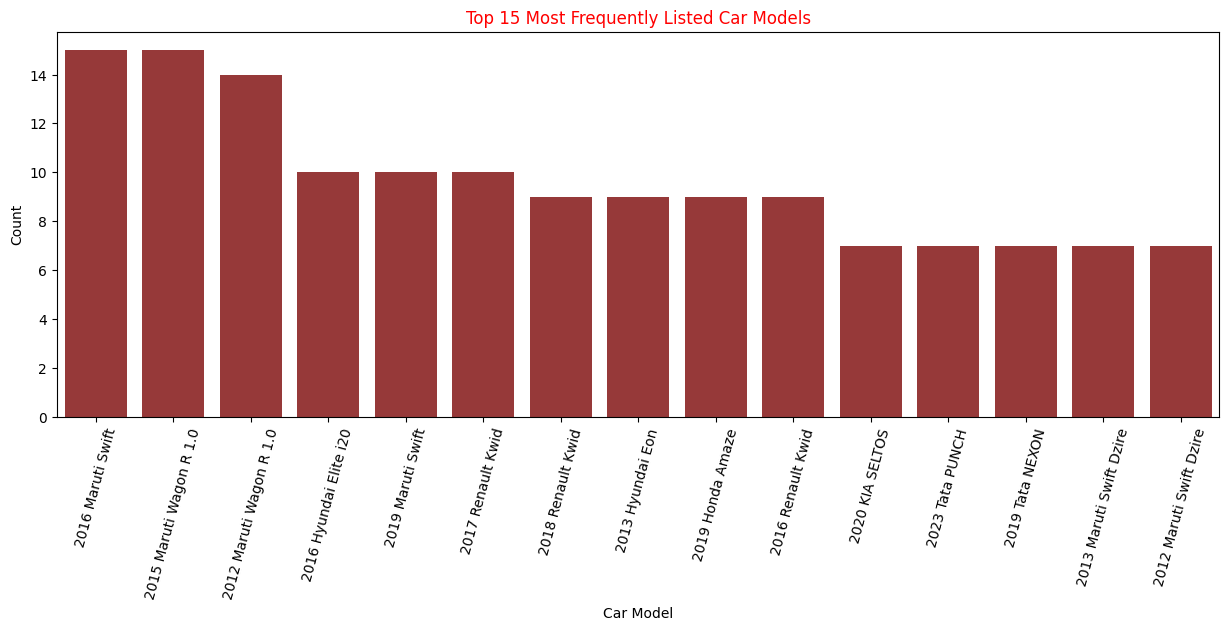

In [422]:
# Visualization
plt.figure(figsize=(15,5))
sns.barplot(x=model_counts.index, y=model_counts.values,color='brown')
plt.title("Top 15 Most Frequently Listed Car Models",color='red')
plt.xlabel("Car Model")
plt.ylabel("Count")
plt.xticks(rotation=75)
plt.show()

10. Which brands exhibit the greatest price variability across their listings?

In [423]:
price_variability = (df.groupby("Brand")["Final Price"].std().sort_values(ascending=False)).head(15)
print(price_variability)

Brand
Nissan        863003.685456
Maruti        336104.164931
Chevrolet     334131.678011
Mahindra      314739.057119
Volkswagen    311143.696352
KIA           308300.775993
Tata          297675.395988
Honda         253165.501095
Volvo         236881.478804
Hyundai       236650.104867
Toyota        230443.326366
Ford          224837.336653
Skoda         197759.473917
Datsun        170524.698291
MG            170164.672345
Name: Final Price, dtype: float64


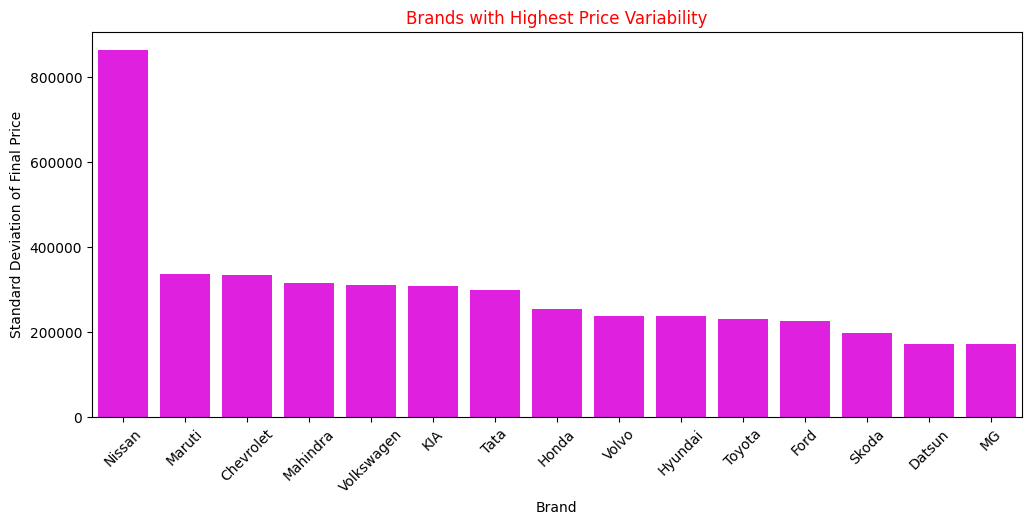

In [424]:
# Visualization
plt.figure(figsize=(12, 5))
sns.barplot(x=price_variability.index, y=price_variability.values,color='magenta')
plt.title("Brands with Highest Price Variability",color='red')
plt.xlabel("Brand")
plt.ylabel("Standard Deviation of Final Price")
plt.xticks(rotation=45)
plt.show()

11. Are premium brands less affected by depreciation than economy brands?

In [425]:
current_year = 2026
temp_df = df.copy()
temp_df["Age"] = current_year - temp_df["year"]

# Define brands into premium and economy
premium = ["BMW", "Audi", "Mercedes-Benz", "Volvo", "Jaguar", "Land Rover"]
economy = ["Maruti", "Hyundai", "Tata", "Honda", "Renault", "Nissan"]

premium_avg = (temp_df[temp_df["Brand"].isin(premium)].groupby(["Age","Brand"])["Final Price"].mean())
print("Premium brands by age:")
print(premium_avg)

economy_avg = (temp_df[temp_df["Brand"].isin(economy)].groupby(["Age",'Brand'])["Final Price"].mean())
print("\nEconomy brands by age:")
print(economy_avg)

Premium brands by age:
Age  Brand 
9    Volvo     561000.0
11   Jaguar    150000.0
12   Volvo     225999.0
15   Audi      183500.0
Name: Final Price, dtype: float64

Economy brands by age:
Age  Brand  
1    Hyundai    490000.000000
     Maruti     190000.000000
2    Hyundai    354000.000000
     Maruti     557333.000000
     Tata       447999.500000
                    ...      
14   Maruti     311428.571429
     Nissan     165000.000000
     Renault    400000.000000
15   Hyundai    280600.000000
     Maruti     336833.000000
Name: Final Price, Length: 67, dtype: float64


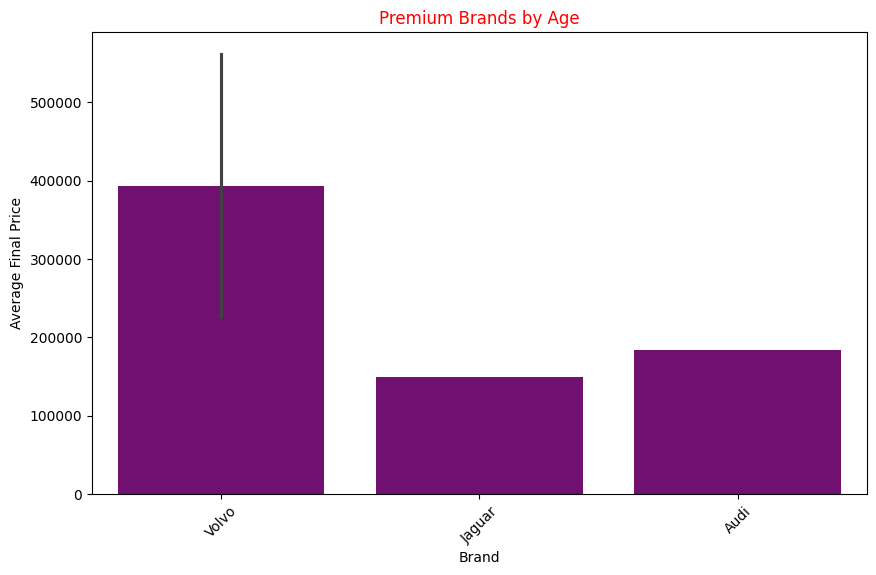

In [426]:
plt.figure(figsize=(10, 6))
sns.barplot(x=premium_avg.index.get_level_values(1),y=premium_avg.values,color='purple')
plt.title("Premium Brands by Age",color='red')
plt.xlabel("Brand")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

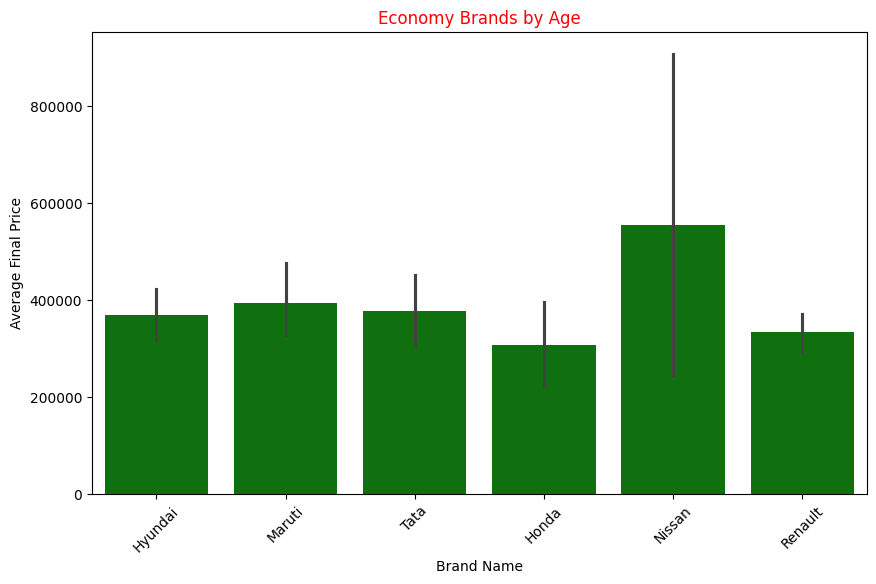

In [427]:
plt.figure(figsize=(10, 6))
sns.barplot(x=economy_avg.index.get_level_values(1),y=economy_avg.values,color='green')
plt.title("Economy Brands by Age",color='red')
plt.xlabel("Brand Name")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

12. How does the average selling prices of car brrand goes across the state?

In [467]:
state_brand=df.groupby(['state',"Brand"])['Final Price'].mean().sort_values(ascending=False).head(10)
state_brand

state  Brand    
WB     Nissan       2.874000e+06
AS     Maruti       1.080000e+06
HR     Jeep         1.030000e+06
PB     KIA          9.615000e+05
CH     Honda        7.686667e+05
WB     Chevrolet    7.100000e+05
       Tata         6.930000e+05
UP     Nissan       6.602500e+05
PB     Skoda        6.470000e+05
DL     Maruti       6.023333e+05
Name: Final Price, dtype: float64

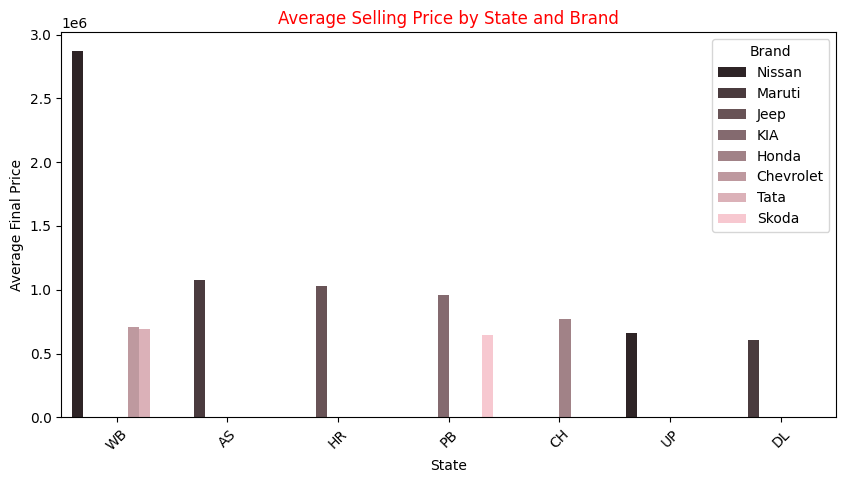

In [468]:
plt.figure(figsize=(10, 5))
sns.barplot(x=state_brand.index.get_level_values(0), y=state_brand.values,hue=state_brand.index.get_level_values(1),palette="dark:pink")
plt.title("Average Selling Price by State and Brand",color='red')
plt.xlabel("State")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

13. Which brands retain higher resale values even after high kilometers?

In [430]:
# Cars driven more than 1 lakh kilometers
high_km = df[df["Kilometers"] >= 100000]
brand_resale = (high_km.groupby("Brand")["Final Price"].mean().sort_values(ascending=False))
print(brand_resale)

Brand
Chevrolet     781999.500000
Skoda         647000.000000
Honda         493333.333333
Tata          419666.666667
Volvo         393499.500000
Ford          392000.000000
Volkswagen    379363.454545
Hyundai       376209.255814
Maruti        373266.600000
Toyota        358454.545455
Datsun        321400.000000
Renault       293099.900000
KIA           290999.875000
Mahindra      280909.090909
Audi          183500.000000
Jaguar        150000.000000
Nissan        132500.000000
Name: Final Price, dtype: float64


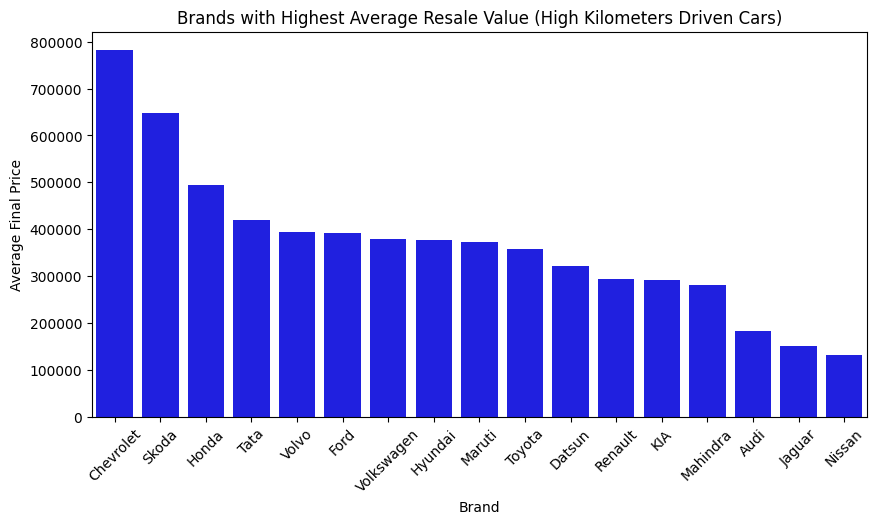

In [431]:
# Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x=brand_resale.index, y=brand_resale.values,color='blue')
plt.title("Brands with Highest Average Resale Value (High Kilometers Driven Cars)")
plt.xlabel("Brand")
plt.ylabel("Average Final Price")
plt.xticks(rotation=45)
plt.show()

14. What is the average mileage for cars in each price segment?

In [432]:
# Create price segments without adding a new column
budget = df[df["Final Price"] < 500000]["Kilometers"].mean()
mid_range = df[(df["Final Price"] >= 500000) &(df["Final Price"] <= 1500000)]["Kilometers"].mean()
premium = df[df["Final Price"] > 1500000]["Kilometers"].mean()

print("Budget Cars Average Mileage:", round(budget, 2))
print("Mid-range Cars Average Mileage:", round(mid_range, 2))
print("Premium Cars Average Mileage:", round(premium, 2))

Budget Cars Average Mileage: 83603.48
Mid-range Cars Average Mileage: 81363.72
Premium Cars Average Mileage: 78939.43


15. Are there unusual listings where high-mileage cars are priced significantly above market expectations?

In [433]:
# High mileage (>100,000 km) and expensive (>75th percentile)
price_= df["Final Price"].quantile(0.75)
unusual = df[(df["Kilometers"] >= 100000) &(df["Final Price"] >= price_)]
print(unusual[["Car Name", "Brand", "Kilometers", "Final Price"]])

                       Car Name       Brand  Kilometers  Final Price
95              2017 Honda WR-V       Honda      135411       601000
113     2016 Maruti Wagon R 1.0      Maruti      169642       475000
132         2013 Renault Duster     Renault      142829       750000
136     2015 Maruti Wagon R 1.0      Maruti      137902       570000
145        2014 Maruti Alto 800      Maruti      116806       656000
190      2015 Hyundai Grand i10     Hyundai      119013       469000
196            2013 Hyundai i20     Hyundai      125150       479000
202          2017 Hyundai Creta     Hyundai      102752       536000
217        2018 Toyota Fortuner      Toyota      140014       900000
228            2013 Hyundai Eon     Hyundai      115168       521000
233             2017 Honda WR-V       Honda      252995      1120000
245        2020 Maruti S PRESSO      Maruti      120704       470000
258           2011 Toyota Etios      Toyota      131039       515000
260   2016 Maruti Vitara Brezza   

16. Is there a mileage threshold beyond which resale prices decline sharply?

In [434]:
# Create mileage bins
bins = [0, 25000, 50000, 75000, 100000, 150000, df["Kilometers"].max()]
labels = ["0-25k", "25k-50k", "50k-75k","75k-100k", "100k-150k", "150k+"]
avg_prices = (df.groupby(pd.cut(df["Kilometers"], bins=bins, labels=labels))["Final Price"].mean())
print(avg_prices)

Kilometers
0-25k        481833.291667
25k-50k      379809.466667
50k-75k      396255.385870
75k-100k     341867.044304
100k-150k    359702.078014
150k+        387404.642857
Name: Final Price, dtype: float64


/tmp/ipykernel_2553/3939811418.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_prices = (df.groupby(pd.cut(df["Kilometers"], bins=bins, labels=labels))["Final Price"].mean())


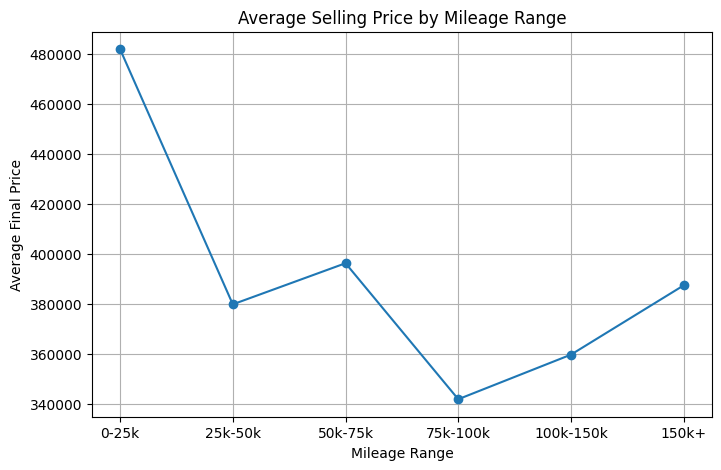

In [435]:
# visualization
plt.figure(figsize=(8, 5))
plt.plot(avg_prices.index.astype(str), avg_prices.values, marker="o")
plt.xlabel("Mileage Range")
plt.ylabel("Average Final Price")
plt.title("Average Selling Price by Mileage Range")
plt.grid(True)
plt.show()

17. Which fuel type dominates the used car market?

In [436]:
# Count of cars by fuel type
df["Fuel"].value_counts()

,count
Fuel,
Petrol,382
Diesel,176
CNG,96


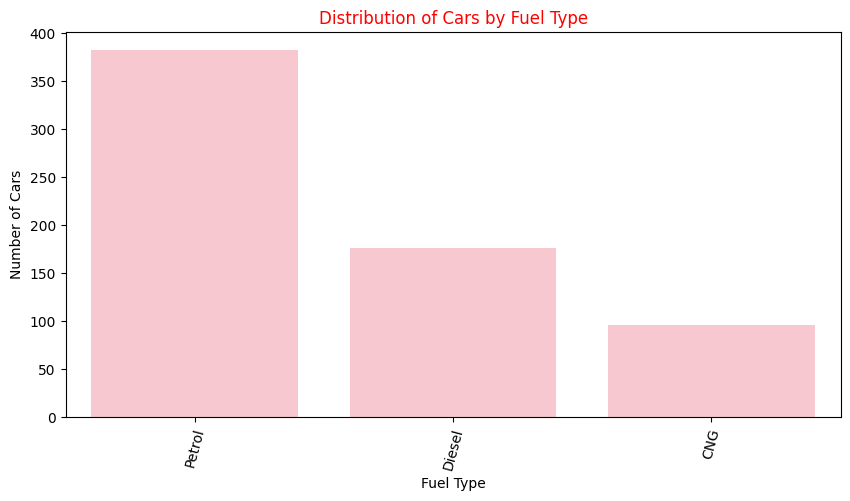

In [437]:
# Bar chart
plt.figure(figsize=(10, 5))
sns.barplot(x=df["Fuel"].value_counts().index, y=df["Fuel"].value_counts().values,color='pink')
plt.title("Distribution of Cars by Fuel Type",color='red')
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.xticks(rotation=75)
plt.show()

18. Do diesel cars have higher average resale values than petrol cars?

In [438]:
# Average resale price by fuel type
avg_price = (df.groupby("Fuel")["Final Price"].mean().sort_values(ascending=False))
print(avg_price)

Fuel
Petrol    383604.662304
CNG       375093.708333
Diesel    356891.977273
Name: Final Price, dtype: float64


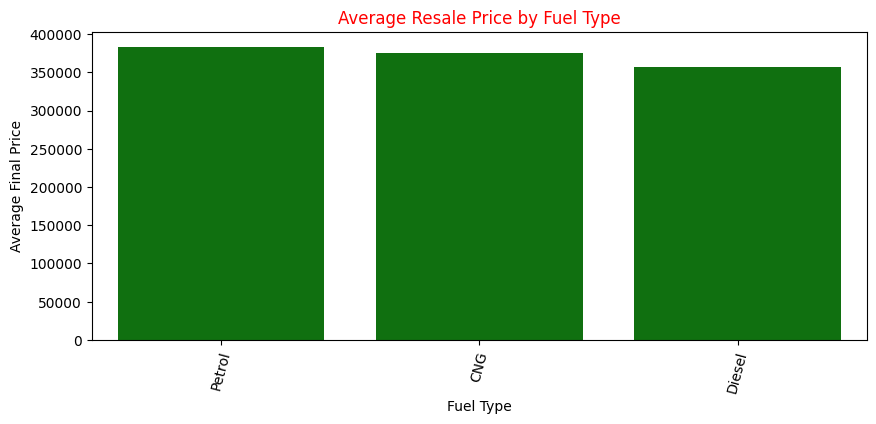

In [439]:
# Visualization
plt.figure(figsize=(10,4))
sns.barplot(x=avg_price.index, y=avg_price.values,color='green')
plt.title("Average Resale Price by Fuel Type",color='red')
plt.xlabel("Fuel Type")
plt.ylabel("Average Final Price")
plt.xticks(rotation=75)
plt.show()

19. Which fuel type offers the best balance between affordability and resale value?

In [440]:
# Average price and average kilometers by fuel type
fuel_summary = (df.groupby("Fuel").agg({"Final Price": "mean","Kilometers": "mean"}).sort_values(by="Final Price"))
print(fuel_summary)

          Final Price     Kilometers
Fuel                                
Diesel  356891.977273  111339.846591
CNG     375093.708333   85538.239583
Petrol  383604.662304   69549.136126


20. How does fuel type affect average vehicle mileage and price?

In [441]:
# Summary statistics
fuel_analysis = (df.groupby("Fuel").agg(Average_Kilometers=("Kilometers", "mean"),Average_Price=("Final Price", "mean")).round(2))
print(fuel_analysis)

        Average_Kilometers  Average_Price
Fuel                                     
CNG               85538.24      375093.71
Diesel           111339.85      356891.98
Petrol            69549.14      383604.66


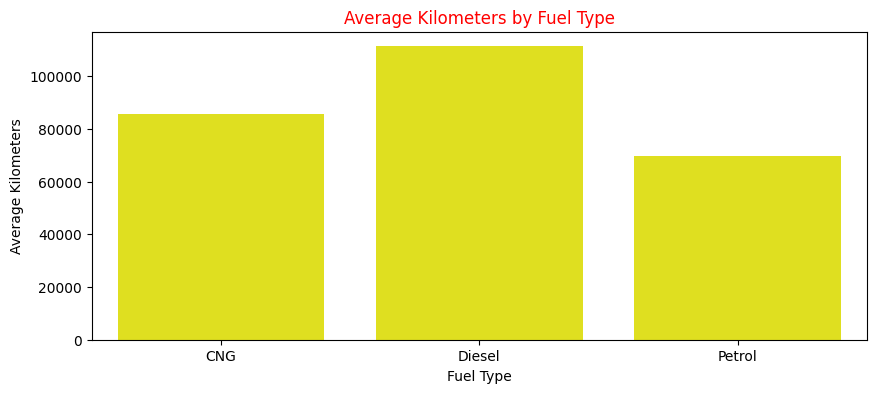

In [442]:
#Visualization
plt.figure(figsize=(10,4))
sns.barplot(x=fuel_analysis['Average_Kilometers'].index, y=fuel_analysis['Average_Kilometers'].values,color='yellow')
plt.title("Average Kilometers by Fuel Type",color='red')
plt.xlabel("Fuel Type")
plt.ylabel("Average Kilometers")
plt.xticks(rotation=0)
plt.show()

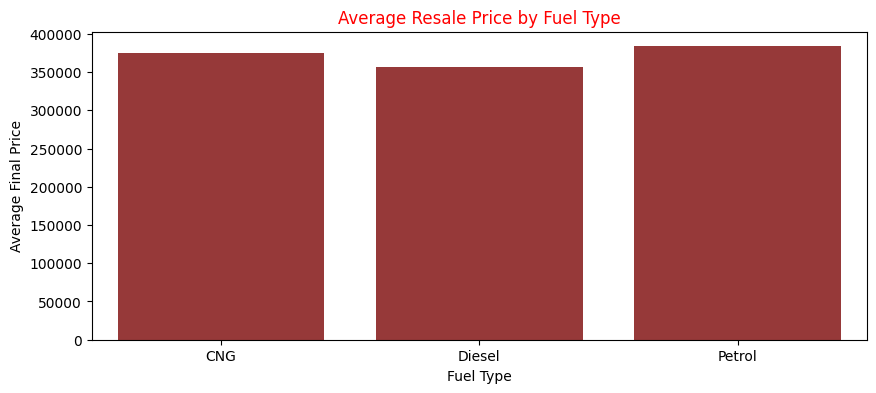

In [443]:
#visualization
plt.figure(figsize=(10,4))
sns.barplot(x=fuel_analysis['Average_Price'].index, y=fuel_analysis['Average_Price'].values,color='brown')
plt.title("Average Resale Price by Fuel Type",color='red')
plt.xlabel("Fuel Type")
plt.ylabel("Average Final Price")
plt.xticks(rotation=0)
plt.show()

21. What proportion of listings are Manual vs Automatic?

In [444]:
transmission_percent = (df["Transmission"].value_counts(normalize=True)*100)
print(transmission_percent)

Transmission
Manual    100.0
Name: proportion, dtype: float64


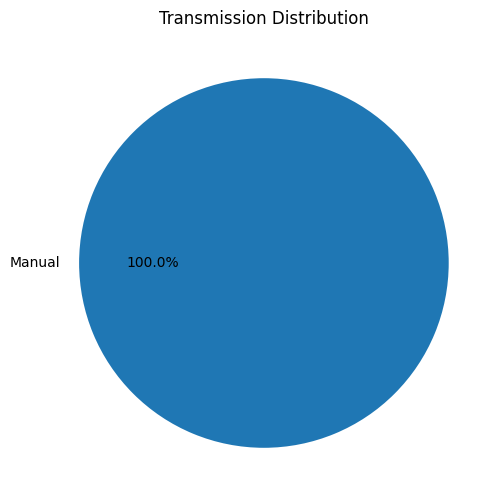

In [445]:
plt.figure(figsize=(6,6))
plt.pie(transmission_percent.values,labels=transmission_percent.index,autopct="%1.1f%%")
plt.title("Transmission Distribution")
plt.show()

22. Are newer manual cars concentrated in particular cities or brands?

In [455]:
current_year = 2026
city_age = (df.assign(Age=current_year - df["year"]).groupby(["state","Brand"])["Age"].mean().sort_values(ascending=False)).head(15)
print(city_age)

state  Brand    
CH     Chevrolet    16.0
HR     Audi         15.0
       Chevrolet    15.0
PB     Chevrolet    15.0
UP     Audi         15.0
       Chevrolet    14.5
WB     Chevrolet    14.5
RJ     Honda        14.0
JK     Maruti       14.0
WB     Ford         14.0
       Mahindra     14.0
GJ     Maruti       14.0
AS     Hyundai      14.0
PB     Nissan       13.0
JK     Hyundai      13.0
Name: Age, dtype: float64


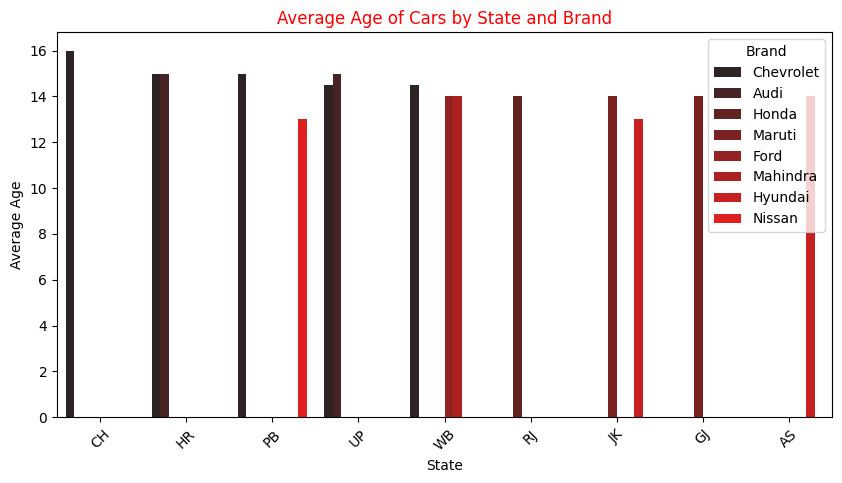

In [462]:
plt.figure(figsize=(10, 5))
sns.barplot(x=city_age.index.get_level_values(0), y=city_age.values,hue=city_age.index.get_level_values(1),palette="dark:red")
plt.title("Average Age of Cars by State and Brand",color='red')
plt.xlabel("State")
plt.ylabel("Average Age")
plt.xticks(rotation=45)
plt.show()